In [5]:
from google.colab import files

uploaded = files.upload()

Saving training_vs_ideal_mapping.zip to training_vs_ideal_mapping.zip


In [6]:
import os
os.listdir('/content')

['.config', 'training_vs_ideal_mapping.zip', 'sample_data']

In [7]:
import zipfile

zip_path = "/content/training_vs_ideal_mapping.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
import os

os.listdir('/content/dataset')

['waterpollution']

In [9]:
import os

dataset_path = "/content/dataset/waterpollution"

print(os.listdir(dataset_path))

['image_085.png', 'image_007.jpg', 'image_216.jpg', 'image_271.jpg', 'image_028.jpeg', 'image_231.jpg', 'image_248.jpg', 'image_047.jpg', 'image_232.jpg', 'image_286.jpg', 'image_135.jpg', 'image_146.jpg', 'image_127.jpg', 'image_270.png', 'image_051.jpeg', 'image_036.jpg', 'image_018.jpg', 'image_180.jpg', 'image_065.jpg', 'image_074.jpg', 'image_166.jpg', 'image_263.jpg', 'image_113.jpg', 'image_150.jpg', 'image_260.jpg', 'image_281.jpg', 'image_148.JPG', 'image_012.jpg', 'image_245.png', 'image_162.jpg', 'image_172.jpg', 'image_129.jpg', 'image_190.jpg', 'image_031.jpg', 'image_039.jpg', 'image_289.jpg', 'image_168.jpg', 'image_183.jpg', 'image_272.jpg', 'image_152.jpg', 'image_061.jpg', 'image_182.jpg', 'image_256.jpg', 'image_274.jpg', 'image_188.jpg', 'image_006.png', 'image_292.jpg', 'image_084.jpg', 'image_116.jpg', 'image_111.jpg', 'image_221.jpg', 'image_140.jpg', 'image_020.jpg', 'image_197.jpg', 'image_252.jpg', 'image_091.jpg', 'image_101.jpg', 'image_213.jpg', 'image_102.

In [10]:
import os
import shutil
import random

source_folder = "/content/dataset/waterpollution"

base_dir = "/content/water_dataset"
clean_dir = os.path.join(base_dir, "clean")
polluted_dir = os.path.join(base_dir, "polluted")

os.makedirs(clean_dir, exist_ok=True)
os.makedirs(polluted_dir, exist_ok=True)

images = os.listdir(source_folder)
random.shuffle(images)

split_index = len(images) // 2

clean_images = images[:split_index]
polluted_images = images[split_index:]

for img in clean_images:
    shutil.copy(os.path.join(source_folder, img), os.path.join(clean_dir, img))

for img in polluted_images:
    shutil.copy(os.path.join(source_folder, img), os.path.join(polluted_dir, img))

print("Dataset organized successfully!")

Dataset organized successfully!


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/water_dataset"

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 235 images belonging to 2 classes.
Found 58 images belonging to 2 classes.


In [35]:
print("Training Images:", train_data.samples)
print("Validation Images:", val_data.samples)
print("Image Size:", (224,224))
print("Classes:", ["Clean", "Polluted"])

Training Images: 234
Validation Images: 58
Image Size: (224, 224)
Classes: ['Clean', 'Polluted']


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from PIL import Image
import os

dataset_path = "/content/water_dataset"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            img = Image.open(image_path)
            img.verify()

        except:
            print("Removing corrupted image:", image_path)
            os.remove(image_path)

print("Corrupted images removed successfully!")

Removing corrupted image: /content/water_dataset/polluted/image_116.jpg
Corrupted images removed successfully!


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/water_dataset"

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 234 images belonging to 2 classes.
Found 58 images belonging to 2 classes.


In [24]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.6239 - loss: 0.6550 - val_accuracy: 0.4828 - val_loss: 0.7160
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.6111 - loss: 0.6325 - val_accuracy: 0.4138 - val_loss: 0.7366
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.6838 - loss: 0.6162 - val_accuracy: 0.4310 - val_loss: 0.7360
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.7308 - loss: 0.5526 - val_accuracy: 0.3966 - val_loss: 0.8284
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.7906 - loss: 0.4846 - val_accuracy: 0.4310 - val_loss: 0.8396


In [25]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


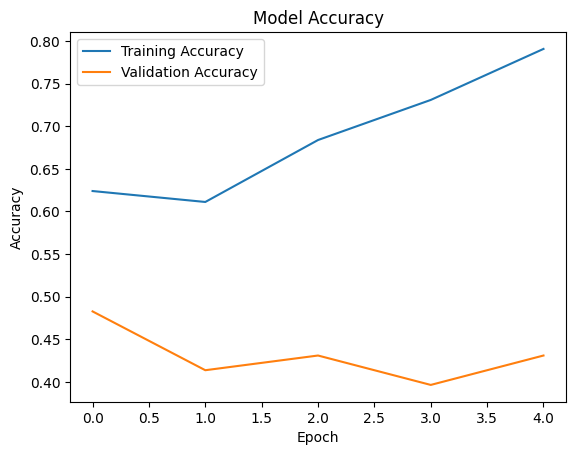

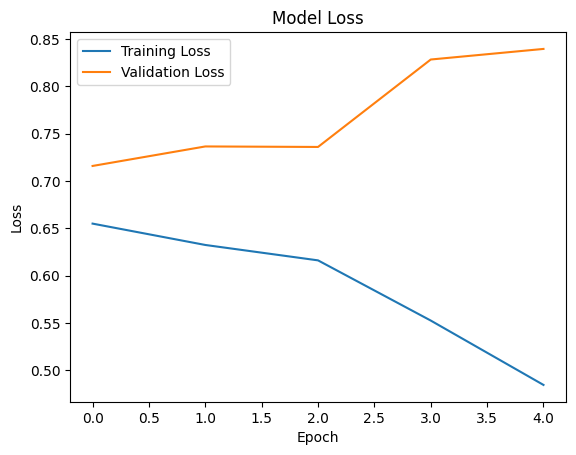

In [27]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 730ms/step - accuracy: 0.4310 - loss: 0.8396
Validation Accuracy: 0.43103447556495667
Validation Loss: 0.8396275043487549


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
Confusion Matrix:
[[15 14]
 [17 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.52      0.49        29
           1       0.46      0.41      0.44        29

    accuracy                           0.47        58
   macro avg       0.47      0.47      0.46        58
weighted avg       0.47      0.47      0.46        58



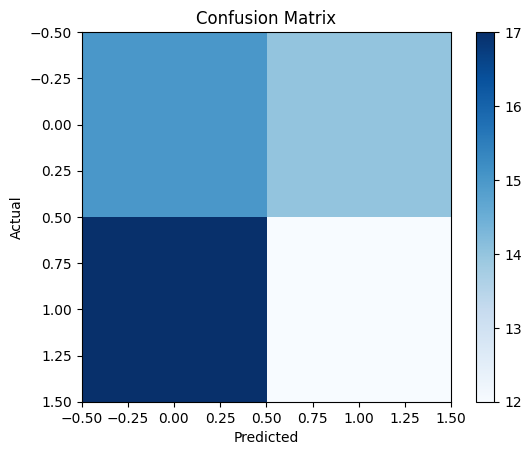

In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

predictions = model.predict(val_data)
predicted_classes = (predictions > 0.5).astype(int)

true_classes = val_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes))

plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [30]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [31]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
5/8 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.4768 - loss: 0.7537

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.4829 - loss: 0.7899 - val_accuracy: 0.4655 - val_loss: 0.7952
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5470 - loss: 0.7304 - val_accuracy: 0.4828 - val_loss: 0.8281
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5897 - loss: 0.6799 - val_accuracy: 0.4828 - val_loss: 0.7817
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6453 - loss: 0.6469 - val_accuracy: 0.5172 - val_loss: 0.7809
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6752 - loss: 0.6140 - val_accuracy: 0.5000 - val_loss: 0.7977


In [33]:
loss, accuracy = mobilenet_model.evaluate(val_data)

print("MobileNetV2 Validation Accuracy:", accuracy)
print("MobileNetV2 Validation Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 857ms/step - accuracy: 0.5000 - loss: 0.7977
MobileNetV2 Validation Accuracy: 0.5
MobileNetV2 Validation Loss: 0.797747015953064


In [34]:
print("CNN Validation Accuracy:",
      history.history['val_accuracy'][-1])

print("MobileNetV2 Validation Accuracy:",
      mobilenet_history.history['val_accuracy'][-1])

CNN Validation Accuracy: 0.43103447556495667
MobileNetV2 Validation Accuracy: 0.5


## Model Comparison

The CNN model achieved a validation accuracy of 43.1%, while MobileNetV2 achieved 50.0%.

The relatively low performance is likely due to limitations in the dataset quality, class labeling process, and dataset size. Future work could include using a larger labeled dataset, hyperparameter tuning, and advanced transfer learning techniques.